In [1]:
import pandas as pd
df = pd.read_csv('Datasets/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(columns=['PassengerId','Name','Parch','Ticket'],inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Fare,Cabin,Embarked
0,0,3,male,22.0,1,7.2500,NaN,S
1,1,1,female,38.0,1,71.2833,C85,C
2,1,3,female,26.0,0,7.9250,NaN,S
3,1,1,female,35.0,1,53.1000,C123,S
4,0,3,male,35.0,0,8.0500,NaN,S


In [5]:
df.drop('Cabin',axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,male,22.0,1,7.2500
1,1,1,female,38.0,1,71.2833
2,1,3,female,26.0,0,7.9250
3,1,1,female,35.0,1,53.1000
4,0,3,male,35.0,0,8.0500


In [6]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Fare          0
dtype: int64

In [8]:
age_groups=df.groupby('Sex')['Age'].mean()
age_groups['male']

np.float64(30.72664459161148)

In [10]:
df['Age']=df.apply(lambda x:age_groups[x['Sex']] if pd.isnull(x['Age'])
                  else x['Age'], axis=1)
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Fare        0
dtype: int64

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,male,22.0,1,7.2500
1,1,1,female,38.0,1,71.2833
2,1,3,female,26.0,0,7.9250
3,1,1,female,35.0,1,53.1000
4,0,3,male,35.0,0,8.0500


In [12]:
inputs=df.drop('Survived',axis=1)
target=df.Survived

In [13]:
inputs['Sex']=inputs.apply(lambda x:1 if x['Sex']=='male'
                          else 0,axis=1)
inputs.head()

,Pclass,Sex,Age,SibSp,Fare
0,3,1,22.0,1,7.2500
1,1,0,38.0,1,71.2833
2,3,0,26.0,0,7.9250
3,1,0,35.0,1,53.1000
4,3,1,35.0,0,8.0500


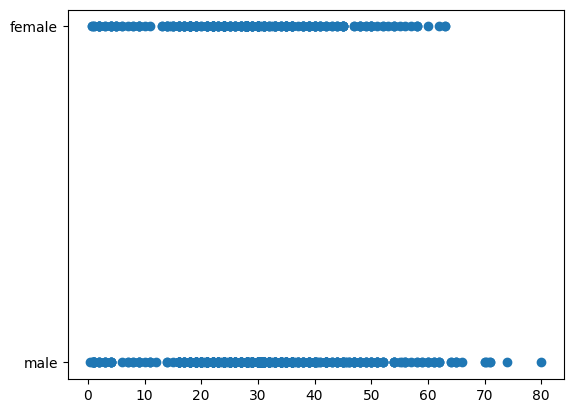

In [17]:
from matplotlib import pyplot as plt
plt.scatter(df['Age'],df['Sex'])
plt.show()

In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test= train_test_split(inputs,target,test_size=0.2,random_state=4)

In [31]:
from sklearn.naive_bayes import GaussianNB
model= GaussianNB()

In [35]:
model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [36]:
model.score(X_test,y_test)

0.8156424581005587

In [39]:
cross_val_score(GaussianNB(),inputs,target)

array([0.75977654, 0.79775281, 0.79213483, 0.78651685, 0.79213483])

In [40]:
model.predict_proba(X_test[:10])

array([[0.92852804, 0.07147196],
       [0.9308563 , 0.0691437 ],
       [0.33661962, 0.66338038],
       [0.07128452, 0.92871548],
       [0.99813417, 0.00186583],
       [0.67581104, 0.32418896],
       [0.09942776, 0.90057224],
       [0.3578923 , 0.6421077 ],
       [0.5340316 , 0.4659684 ],
       [0.88556155, 0.11443845]])

## Naive Bayes 2
### Spam/Ham classification

In [41]:
df2 =pd.read_csv('Datasets/spam.csv')
df2.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [43]:
df2.Category= df2.apply(lambda x: 1 if x['Category']=='spam'
                       else 0, axis=1)

In [44]:
df2.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
0           4825   4516                             Sorry, I'll call later   
1            747    641  Please call our customer service representativ...   

               
         freq  
Category       
0          30  
1           4

In [67]:
inputs=df2.Message
target=df2.Category

In [68]:
from sklearn.feature_extraction.text import CountVectorizer
v=CountVectorizer()
input_count=v.fit_transform(inputs.values)
input_count.toarray()[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 8709))

In [69]:
X_train,X_test,y_train,y_test=train_test_split(input_count,target,test_size=0.25)

In [70]:
from sklearn.naive_bayes import MultinomialNB
model= MultinomialNB()
model.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [76]:
emails=[
    'Hey mohan, can we get together to watch football game tomorrow?',
    'Up to 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]
emails_count =v.transform(emails)
model.predict(emails_count)

array([0, 1])

In [74]:
model.score(X_test,y_test)

0.9813352476669059

In [80]:
#pipeline feature to define pipeline of transformation
from sklearn.pipeline import Pipeline
clf = Pipeline([
    ('vectorizer',CountVectorizer()), #step1
    ('nb',MultinomialNB()) #step2
])
#research more on this when u have data

In [78]:
clf.fit(inputs,target)

,steps,"[('vectorizer', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [79]:
clf.predict(emails)

array([0, 1])

## ASS 
### Use wine dataset in sklearn

In [81]:
from sklearn.datasets import load_wine

In [82]:
wine=load_wine()
dir(wine)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [87]:
df3=pd.DataFrame(wine.data,columns=wine.feature_names)
df3.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [88]:
df3['target']=wine.target
df3.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
